In [1]:
# Data loading and database setup

In [2]:
!pip install numpy pandas matplotlib seaborn

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [4]:
import sys
print(sys.executable)

C:\Users\suhan\AppData\Local\Programs\Python\Python314\python.exe


In [5]:
import sys

!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install openpyxl

In [6]:
import openpyxl

print(openpyxl.__version__)

3.1.5


In [7]:
import pandas as pd

customer = pd.read_excel(
    "customer_churn_data_expanded.xlsx",
    sheet_name="db_customer"
)

subscription = pd.read_excel(
    "customer_churn_data_expanded.xlsx",
    sheet_name="db_subscription"
)

support = pd.read_excel(
    "customer_churn_data_expanded.xlsx",
    sheet_name="db_support"
)

In [8]:
import sqlite3

conn = sqlite3.connect("customer_churn.db")

customer.to_sql("db_customer", conn, if_exists="replace", index=False)
subscription.to_sql("db_subscription", conn, if_exists="replace", index=False)
support.to_sql("db_support", conn, if_exists="replace", index=False)

conn.commit()

In [9]:
# Data Import: db file to pandas, storing each table to a separate df

# Connect to SQLite database
conn = sqlite3.connect('customer_churn.db')

# sql query to Get all table names
sql_query = """
        SELECT name
        FROM sqlite_master
        WHERE type='table';
"""

# read sql query in pandas
tables = pd.read_sql(sql_query, conn)

# create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn) # Read table into dataframe
    globals()[f"df_{table_name}"] = df                    # Create dynamic dataframe name
    print(f"Created dataframe: df_{table_name}")

# Close connection


Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [10]:
# Print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close connection



Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [11]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,10001,Rahul10001,India,Gujarat,Male,1992-05-19,Sports,507928
1,10002,Rahul10002,India,Gujarat,Male,2001-12-03,Gaming,862894
2,10003,Rahul10003,India,Maharashtra,Male,1977-08-25,Movies,444695
3,10004,Rahul10004,India,West Bengal,Male,1983-11-08,Movies,503443
4,10005,Priya10005,India,Tamil Nadu,Female,1988-01-13,Kids,218676


In [12]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   customerid  10000 non-null  int64
 1   name        10000 non-null  str  
 2   country     10000 non-null  str  
 3   state       10000 non-null  str  
 4   gender      10000 non-null  str  
 5   dob         10000 non-null  str  
 6   interests   10000 non-null  str  
 7   pincode     10000 non-null  int64
dtypes: int64(2), str(6)
memory usage: 625.1 KB


In [13]:
print(df_db_support['escalations'].value_counts())

escalations
Y    3346
N    1115
Name: count, dtype: int64


In [14]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
9995,19996,Rahul19996,India,Maharashtra,Male,1996-12-04,Movies,182461
9996,19997,Rahul19997,India,Maharashtra,Male,1999-01-19,Kids,553021
9997,19998,Rahul19998,India,West Bengal,Male,1984-05-24,Music,476923
9998,19999,Priya19999,India,Tamil Nadu,Female,1988-01-16,Kids,722847
9999,20000,Rahul20000,India,Karnataka,Male,1998-05-19,Gaming,619429


In [15]:
# a. rename col - name to customer_name
# b. drop columns - interest and pincode
# c. change data type - dob
# d. data standardization - gender
# e. fix missing values (using existing data) - country

In [16]:
# a. rename col - name to customer_name

df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace= True)

In [17]:
# b. drop columns - interest and pincode

# df_db_customer.drop(df_db_customer.columns[-2:], axis=1)


df_db_customer.drop(columns=['interests', 'pincode'], inplace=True)

In [18]:
# c. change data type - dob

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [19]:
# d. data standardization - gender

# df_db_customer['gender'].unique()
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [20]:
# d. data standardization - gender

# df_db_customer['gender'].unique()
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [21]:
# country and state - unique value pair

# Creating state → country map from non-null rows
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

# Fill the missing country using State
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [22]:
df_db_customer[df_db_customer['country'].isna()] # no null value in country col

,customerid,customer_name,country,state,gender,dob


In [23]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     10000 non-null  int64         
 1   customer_name  10000 non-null  str           
 2   country        10000 non-null  str           
 3   state          10000 non-null  str           
 4   gender         10000 non-null  str           
 5   dob            10000 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(1), str(4)
memory usage: 468.9 KB


In [24]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,10001,2023-05-22,Basic,2023-08-20,Basic,Quarterly,2023-08-20,Price,199,3582,0.94
1,10002,2024-02-01,Basic,2024-05-01,Basic,Quarterly,NaN,NaN,199,4378,0.46
2,10003,2022-03-22,Premium,2022-04-21,Premium,Monthly,NaN,NaN,799,12784,0.23
3,10004,2024-07-04,Premium,2025-07-04,Premium,Annual,2025-07-04,Service,799,16779,0.77
4,10005,2023-12-31,Premium,2024-12-30,Premium,Annual,2024-12-30,Service,799,27965,0.99


In [25]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               10000 non-null  int64  
 1   subscription_start_date  10000 non-null  str    
 2   subscription_type        10000 non-null  str    
 3   renewal_date             10000 non-null  str    
 4   plan_type                10000 non-null  str    
 5   contract_type            10000 non-null  str    
 6   cancellation_date        2372 non-null   str    
 7   cancellation_reason      2372 non-null   str    
 8   monthly_charges          10000 non-null  int64  
 9   cltv                     10000 non-null  int64  
 10  churn_score              10000 non-null  float64
dtypes: float64(1), int64(3), str(7)
memory usage: 859.5 KB


In [26]:
# change data type to date - subscription_start_date , renewal_date, cancellation_date
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               10000 non-null  int64         
 1   subscription_start_date  10000 non-null  datetime64[us]
 2   subscription_type        10000 non-null  str           
 3   renewal_date             10000 non-null  datetime64[us]
 4   plan_type                10000 non-null  str           
 5   contract_type            10000 non-null  str           
 6   cancellation_date        2372 non-null   datetime64[us]
 7   cancellation_reason      2372 non-null   str           
 8   monthly_charges          10000 non-null  int64         
 9   cltv                     10000 non-null  int64         
 10  churn_score              10000 non-null  float64       
dtypes: datetime64[us](3), float64(1), int64(3), str(4)
memory usage: 859.5 KB


In [27]:
df_db_support.head() 

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,10002,2024-12-22,N,5,-,Resolved
1,10004,2025-08-30,Y,3,-,Resolved
2,10005,2024-09-04,N,5,-,Slow streaming
3,10008,2025-11-02,Y,2,-,Resolved
4,10012,2024-01-09,N,5,-,Billing issue


In [28]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 4461 entries, 0 to 4460
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customerid      4461 non-null   int64
 1   complaint_date  4461 non-null   str  
 2   escalations     4461 non-null   str  
 3   csat_score      4461 non-null   int64
 4   col_1           4461 non-null   str  
 5   comment         4461 non-null   str  
dtypes: int64(2), str(4)
memory usage: 209.2 KB


In [29]:
# drop columns
df_db_support.drop(columns=['col_1', 'comment'], inplace=True)

In [30]:
# change data type to date - complaint_date

df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 4461 entries, 0 to 4460
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      4461 non-null   int64         
 1   complaint_date  4461 non-null   datetime64[us]
 2   escalations     4461 non-null   str           
 3   csat_score      4461 non-null   int64         
dtypes: datetime64[us](1), int64(2), str(1)
memory usage: 139.5 KB


In [31]:
# create a new col using existing col - churn flag

# Customer is churned if cancellation_date is not null
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,10001,2023-05-22,Basic,2023-08-20,Basic,Quarterly,2023-08-20,Price,199,3582,0.94,1
1,10002,2024-02-01,Basic,2024-05-01,Basic,Quarterly,NaT,NaN,199,4378,0.46,0
2,10003,2022-03-22,Premium,2022-04-21,Premium,Monthly,NaT,NaN,799,12784,0.23,0
3,10004,2024-07-04,Premium,2025-07-04,Premium,Annual,2025-07-04,Service,799,16779,0.77,1
4,10005,2023-12-31,Premium,2024-12-30,Premium,Annual,2024-12-30,Service,799,27965,0.99,1


In [32]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,10002,2024-12-22,N,5
1,10004,2025-08-30,Y,3
2,10005,2024-09-04,N,5
3,10008,2025-11-02,Y,2
4,10012,2024-01-09,N,5
...,...,...,...,...
4456,19995,2026-09-10,Y,2
4457,19996,2023-08-09,N,5
4458,19997,2025-02-20,Y,4
4459,19998,2023-08-03,Y,4


In [33]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [34]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep= 'last')

In [35]:
df_db_support['customerid'].size

4461

In [36]:
# SQL analysis

In [37]:
#1-Total Customers
query = """
SELECT COUNT(*) AS total_customers
FROM db_customer;
"""

pd.read_sql_query(query, conn)

,total_customers
0,10000


In [38]:
#2 – Customers by Plan
query = """
SELECT plan_type,
       COUNT(*) AS total_customers
FROM db_subscription
GROUP BY plan_type;
"""

pd.read_sql_query(query, conn)


,plan_type,total_customers
0,Basic,3349
1,Premium,3327
2,Standard,3324


In [39]:
# Customer distribution is relatively balanced across Basic, Standard and Premium plans, reducing the likelihood that overall churn is driven simply by one plan having a much larger customer base.

In [40]:
#3 – Average Revenue by Plan
query = """
SELECT plan_type,
       ROUND(AVG(monthly_charges),2) AS avg_revenue
FROM db_subscription
GROUP BY plan_type;
"""

pd.read_sql_query(query, conn)

,plan_type,avg_revenue
0,Basic,199.0
1,Premium,799.0
2,Standard,499.0


In [41]:
# Premium customers generate approximately 4× the monthly revenue of Basic customers, making retention of premium customers particularly important from a revenue perspective.

In [42]:
#4 – Top 5 Customers by CLTV
query = """
SELECT customerid,
       plan_type,
       cltv
FROM db_subscription
ORDER BY cltv DESC
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,customerid,plan_type,cltv
0,10020,Premium,28764
1,10047,Premium,28764
2,10486,Premium,28764
3,10513,Premium,28764
4,10545,Premium,28764


In [43]:
#5 – Contract Distribution
query = """
SELECT contract_type,
       COUNT(*) AS customers
FROM db_subscription
GROUP BY contract_type;
"""

pd.read_sql_query(query, conn)

,contract_type,customers
0,Annual,3328
1,Monthly,3393
2,Quarterly,3279


In [44]:
# The customer base is relatively evenly distributed across monthly, quarterly and annual contracts, allowing contract-level churn rates to be compared without a major imbalance in customer volume.

In [45]:
#6 – Average Churn Score by Plan
query = """
SELECT plan_type,
       ROUND(AVG(churn_score),2) AS avg_churn_score
FROM db_subscription
GROUP BY plan_type;
"""

pd.read_sql_query(query, conn)

,plan_type,avg_churn_score
0,Basic,0.49
1,Premium,0.50
2,Standard,0.49


In [46]:
# Average churn scores are broadly similar across plans, suggesting that plan type alone does not substantially differentiate the existing churn-risk score.

In [47]:
#7 – Cancellation Reasons
query = """
SELECT cancellation_reason,
       COUNT(*) AS total
FROM db_subscription
WHERE cancellation_reason IS NOT NULL
GROUP BY cancellation_reason
ORDER BY total DESC;
"""

pd.read_sql_query(query, conn)

,cancellation_reason,total
0,Price,611
1,Moved,608
2,Competitor,585
3,Service,568


In [48]:
# Price is the most frequently reported cancellation reason, followed closely by relocation and competitor switching, indicating that churn is driven by a combination of pricing, customer circumstances and competitive pressure.

In [49]:
# merge df
df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how= 'left')
            .merge(df_db_support, on = 'customerid', how= 'left') )

In [50]:
df.shape

(10000, 21)

In [51]:
# export dataframe to csv file
df.to_csv('exported_churn_data.csv', index=False)

In [52]:
# Data Analysis

In [53]:
# 1. Churn Rate
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ", round(churn_rate,2), "%")

Churn Rate =  23.72 %


In [54]:
# 23.72% of customers in the dataset have churned, meaning roughly 1 in 4 customers has discontinued the service.

In [55]:
# 2. Retention Rate
retention_rate = 100 - churn_rate
print("Retention Rate = ", round(retention_rate, 2), "%")


Retention Rate =  76.28 %


In [56]:
# The customer retention rate is 76.28%, with churn representing the remaining 23.72% of the customer base.

In [57]:
# 3. Churn by Plan type
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           23.17
1   Premium           25.04
2  Standard           22.95


In [58]:
# Premium has the highest churn rate at 25.04%, approximately 2.1 percentage points above Standard, while Basic falls in between.

In [59]:
# 4. ARPU - Avg Revenue per user
arpu = df['monthly_charges'].mean()
print('ARPU = ', round(arpu,2))

ARPU =  498.34


In [60]:
#Average monthly revenue per customer is ₹498.34, providing a baseline for evaluating revenue exposure from churn.

In [61]:
# 6. Revenue at risk - revenue lost from churned users
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at Risk  =", revenue_at_risk)

Revenue at Risk  = 1200728


In [62]:
# Churned customers represent approximately ₹12.0 lakh in monthly recurring revenue exposure, highlighting the financial impact of customer attrition.

In [63]:
# 5. Avg Customer Tenure
# count of days users has used our service : cancellation date else current date
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
        df['cancellation_date'].notna(),

    (df['cancellation_date'] - df['subscription_start_date']).dt.days,

    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) =", round(avg_tenure))

Avg Tenure (Days) = 942


In [64]:
# Customers have an average tenure of approximately 942 days, indicating an average relationship length of around 2.6 years.

In [70]:
support_cases = df['csat_score'].notna()

escalation_rate = (
    (df.loc[support_cases, 'escalations'] == 'Y').sum()
    / support_cases.sum()
    * 100
)

print(
    "Escalation Rate among support cases =",
    round(escalation_rate, 2),
    "%"
)

Escalation Rate among support cases = 75.01 %


In [71]:
# 8. Average Recorded Complaints per Customer
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Average Recorded Complaints per Customer =", round(avg_complaints, 2))


Average Recorded Complaints per Customer = 0.45


In [72]:
# Customers generated an average of 0.45 recorded complaints per customer across the full customer base.

In [73]:
print(df['escalations'].unique())

<StringArray>
[nan, 'N', 'Y']
Length: 3, dtype: str


In [74]:
print(df[['escalations']].head(20))

   escalations
0          NaN
1            N
2          NaN
3            Y
4            N
5          NaN
6          NaN
7            Y
8          NaN
9          NaN
10         NaN
11           N
12         NaN
13         NaN
14         NaN
15           N
16           N
17         NaN
18           Y
19         NaN


In [75]:
print(df['escalations'].value_counts())

escalations
Y    3346
N    1115
Name: count, dtype: int64


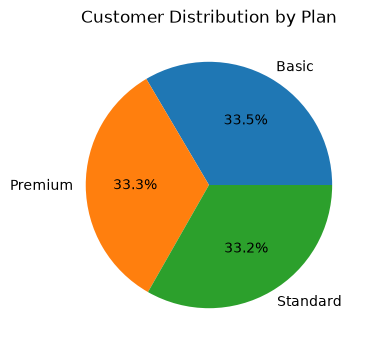

In [76]:
#Customer Distribution by Plan
plan_dist = df['plan_type'].value_counts()

plt.figure(figsize=(6,4))
plt.pie(plan_dist,
        labels=plan_dist.index,
        autopct='%1.1f%%')

plt.title("Customer Distribution by Plan")
plt.show()

In [77]:
# Customer volume is almost evenly distributed across the three plans, providing a balanced basis for plan-level churn comparisons.

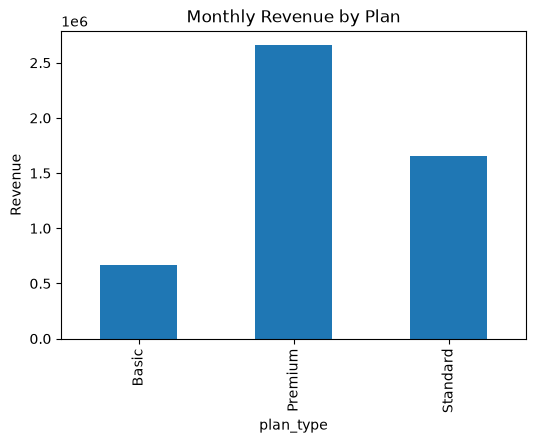

In [80]:
#Monthly Revenue by Plan
revenue = df.groupby('plan_type')['monthly_charges'].sum()

plt.figure(figsize=(6,4))
revenue.plot(kind='bar')

plt.title("Monthly Revenue by Plan")
plt.ylabel("Revenue")
plt.show()

In [81]:
 #Premium  customers contribute disproportionately higher monthly revenue because their average monthly charge is substantially higher than Basic and Standard plans.

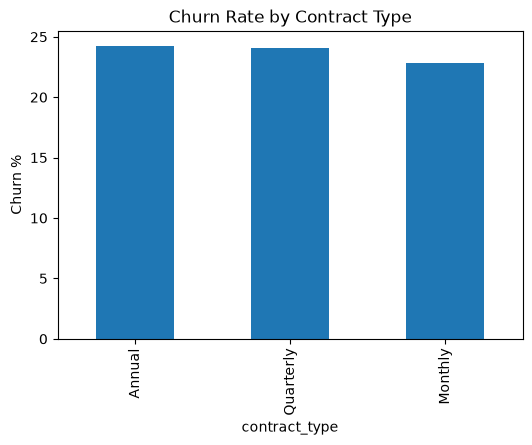

In [82]:
#Churn by Contract Type
churn_contract = (
    df.groupby('contract_type')['churn_flag']
      .mean()
      .sort_values(ascending=False) * 100
)

plt.figure(figsize=(6,4))
churn_contract.plot(kind='bar')

plt.ylabel("Churn %")
plt.title("Churn Rate by Contract Type")
plt.show()

In [83]:
#Add Customer Segmentation
df['customer_segment'] = np.where(
    df['cltv'] > df['cltv'].median(),
    'High Value',
    'Regular'
)

In [84]:
pd.crosstab(df['customer_segment'],
            df['churn_flag'])
#Insight:

#High-value customers should receive proactive retention offer

churn_flag,0,1
customer_segment,,
High Value,3710,1221
Regular,3918,1151


In [85]:
#Visualization using Matplotlib

In [86]:
# best practice to create a copy then work on it
df_visual = df.copy()

In [87]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'customer_segment'],
      dtype='str')

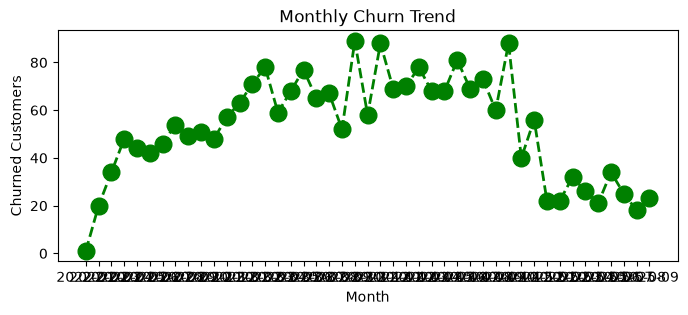

In [88]:
# 4.1 Monthly Churn Trend (Time Series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values,  color='green', marker='o', linestyle='dashed',  linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

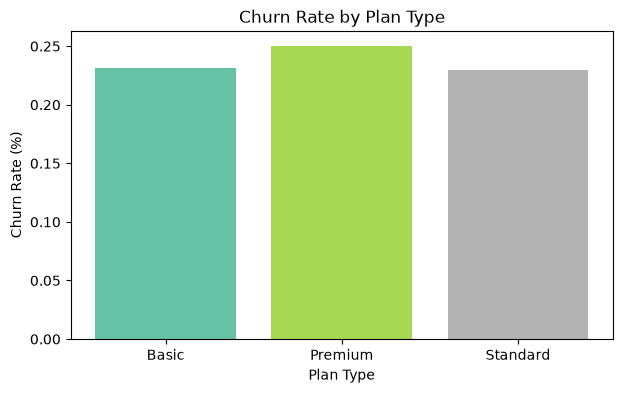

In [89]:
# 4.2 Churn Rate by Plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

# colors = ['yellow', 'purple', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
plt.show()

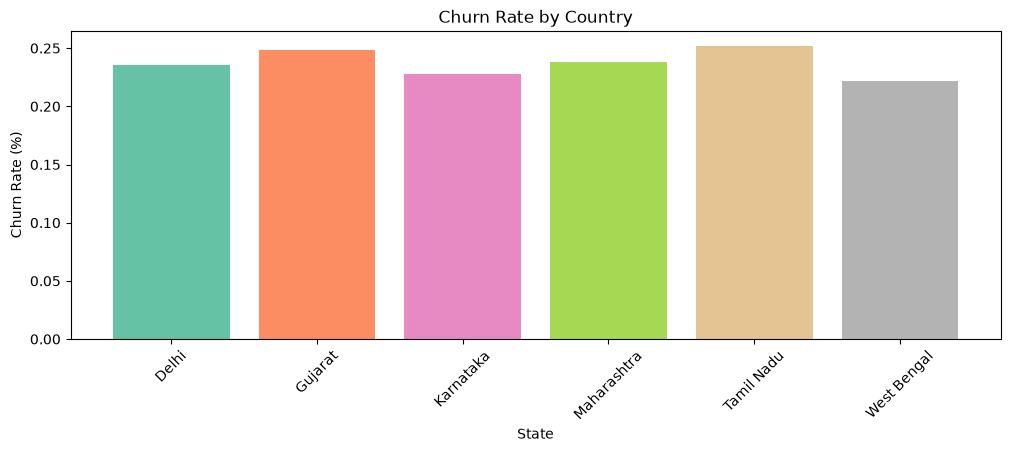

In [90]:
# 4.3 Churn by States
churn_plan = df_visual.groupby('state')['churn_flag'].mean()

# colors = ['yellow', 'purple', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(12,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn Rate by Country')
plt.xlabel('State')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

In [91]:
# Visulaization using Seaborn

In [92]:
# Churn Rate by Customer Satisfaction (CSAT) Score

In [93]:
df['csat_score'].value_counts(dropna=False).sort_index()

csat_score
2.0    1148
3.0    1119
4.0    1079
5.0    1115
NaN    5539
Name: count, dtype: int64

In [94]:
df.groupby('csat_score')['churn_flag'].agg(
    customers='count',
    churned='sum',
    churn_rate='mean'
).reset_index()

,csat_score,customers,churned,churn_rate
0,2.0,1148,264,0.229965
1,3.0,1119,267,0.238606
2,4.0,1079,254,0.235403
3,5.0,1115,249,0.223318


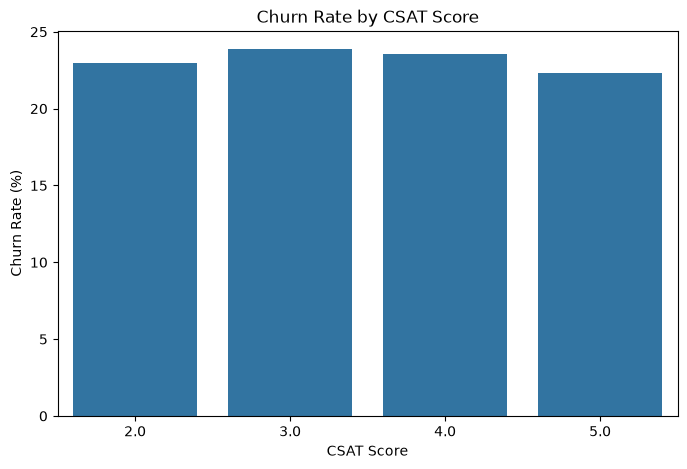

In [95]:
csat_churn = (
    df.groupby('csat_score')['churn_flag']
    .mean()
    .mul(100)
    .reset_index(name='churn_rate')
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=csat_churn,
    x='csat_score',
    y='churn_rate'
)

plt.title('Churn Rate by CSAT Score')
plt.xlabel('CSAT Score')
plt.ylabel('Churn Rate (%)')

plt.show()

In [96]:
# Insight: Churn rate remains relatively stable across CSAT scores, suggesting that CSAT alone is not a strong differentiator of churn risk in this dataset.

## Churn Rate by Plan and Contract Type


In [97]:
plan_contract_churn = (
    df.groupby(['plan_type', 'contract_type'])['churn_flag']
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name='churn_rate')
)

plan_contract_churn

,plan_type,contract_type,churn_rate
0,Basic,Annual,23.51
1,Basic,Monthly,21.55
2,Basic,Quarterly,24.48
3,Premium,Annual,24.48
4,Premium,Monthly,24.56
5,Premium,Quarterly,26.12
6,Standard,Annual,24.86
7,Standard,Monthly,22.38
8,Standard,Quarterly,21.66


## Insight

Premium customers on quarterly contracts have the highest churn rate at **26.12%**, while Basic customers on monthly contracts have the lowest at **21.55%**. Since customer volumes are relatively balanced across segments, the 4.57 percentage-point difference indicates meaningful variation across plan–contract combinations.

**Business implication:** The Premium–Quarterly segment should be prioritized for further investigation and targeted retention efforts.


In [98]:
# How many Premium–Quarterly customers are there?
plan_contract_summary = (
    df.groupby(['plan_type', 'contract_type'])
    .agg(
        customers=('customerid', 'count'),
        churned=('churn_flag', 'sum'),
        churn_rate=('churn_flag', 'mean')
    )
    .reset_index()
)

plan_contract_summary['churn_rate'] = (
    plan_contract_summary['churn_rate'] * 100
).round(2)

plan_contract_summary

,plan_type,contract_type,customers,churned,churn_rate
0,Basic,Annual,1127,265,23.51
1,Basic,Monthly,1123,242,21.55
2,Basic,Quarterly,1099,269,24.48
3,Premium,Annual,1111,272,24.48
4,Premium,Monthly,1144,281,24.56
5,Premium,Quarterly,1072,280,26.12
6,Standard,Annual,1090,271,24.86
7,Standard,Monthly,1126,252,22.38
8,Standard,Quarterly,1108,240,21.66


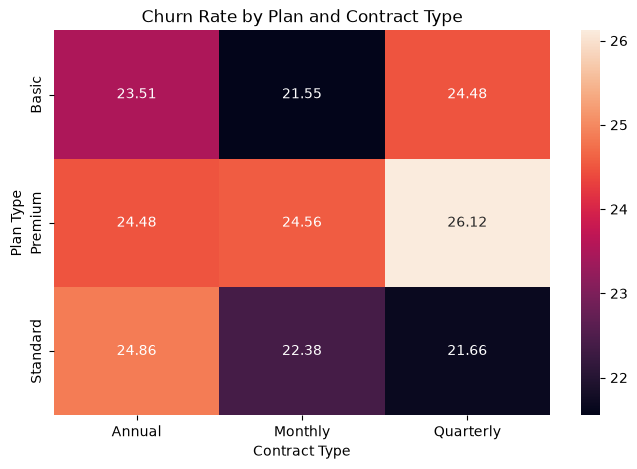

In [99]:
plan_contract_pivot = plan_contract_summary.pivot(
    index='plan_type',
    columns='contract_type',
    values='churn_rate'
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    plan_contract_pivot,
    annot=True,
    fmt='.2f'
)

plt.title('Churn Rate by Plan and Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Plan Type')

plt.show()

In [100]:
#Insight

#Premium customers on quarterly contracts have the highest churn rate at 26.12%, while Basic customers on monthly contracts have the lowest at 21.55%. Since customer volumes are relatively balanced across segments, the 4.57 percentage-point difference suggests that churn varies meaningfully across specific plan–contract combinations.

#Business implication

#The Premium–Quarterly segment should be prioritized for further investigation and targeted retention efforts, particularly to understand why higher-value customers on this contract structure are churning at a higher rate.

In [101]:
# Monthly Revenue at Risk by Plan

In [102]:
revenue_risk_plan = (
    df[df['churn_flag'] == 1]
    .groupby('plan_type')
    .agg(
        churned_customers=('customerid', 'count'),
        monthly_revenue_lost=('monthly_charges', 'sum')
    )
    .reset_index()
)

revenue_risk_plan['revenue_share_pct'] = (
    revenue_risk_plan['monthly_revenue_lost']
    / revenue_risk_plan['monthly_revenue_lost'].sum()
    * 100
).round(2)

revenue_risk_plan

,plan_type,churned_customers,monthly_revenue_lost,revenue_share_pct
0,Basic,776,154424,12.86
1,Premium,833,665567,55.43
2,Standard,763,380737,31.71


## Insight

Premium customers account for **55.43% of the monthly revenue associated with churned customers**, despite representing only 833 churned customers. This makes Premium the most financially significant segment for churn-related revenue protection.

**Business implication:** Retention efforts should prioritize Premium customers because reducing churn in this segment can protect substantially more recurring monthly revenue.


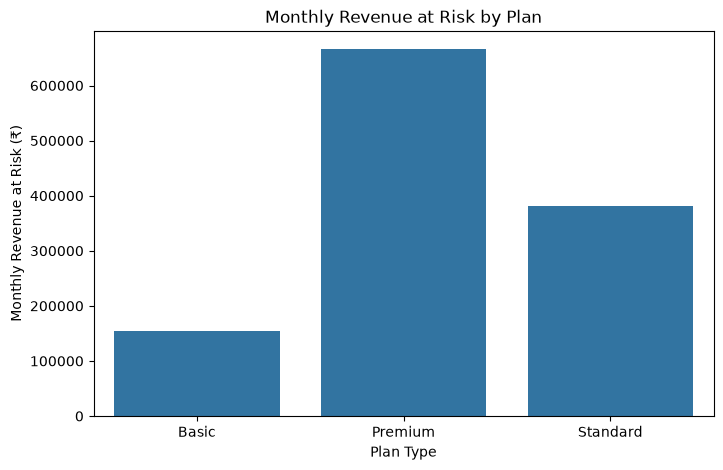

In [103]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=revenue_risk_plan,
    x='plan_type',
    y='monthly_revenue_lost'
)

plt.title('Monthly Revenue at Risk by Plan')
plt.xlabel('Plan Type')
plt.ylabel('Monthly Revenue at Risk (₹)')

plt.show()

In [104]:
#Churn Rate by Customer Value Segment
cltv_churn = (
    df.groupby('customer_segment')
    .agg(
        customers=('customerid', 'count'),
        churned=('churn_flag', 'sum'),
        monthly_revenue=('monthly_charges', 'sum'),
        total_cltv=('cltv', 'sum')
    )
    .reset_index()
)

cltv_churn['churn_rate'] = (
    cltv_churn['churned']
    / cltv_churn['customers']
    * 100
).round(2)

cltv_churn

,customer_segment,customers,churned,monthly_revenue,total_cltv,churn_rate
0,High Value,4931,1221,3302069,80545433,24.76
1,Regular,5069,1151,1681331,24012545,22.71


In [105]:
# High-value customers have a 24.76% churn rate compared with 22.71% for regular customers, a 2.05 percentage-point difference. Since high-value customers represent substantially greater total CLTV, their slightly higher churn rate creates a significant customer-value retention opportunity.

In [106]:
#Churn Rate by Customer Value Segment
cltv_churn['cltv_share_pct'] = (
    cltv_churn['total_cltv']
    / cltv_churn['total_cltv'].sum()
    * 100
).round(2)

cltv_churn

,customer_segment,customers,churned,monthly_revenue,total_cltv,churn_rate,cltv_share_pct
0,High Value,4931,1221,3302069,80545433,24.76,77.03
1,Regular,5069,1151,1681331,24012545,22.71,22.97


## Insight

High-value customers have a **24.76% churn rate** compared with **22.71%** for regular customers. More importantly, high-value customers account for **77.03% of total customer lifetime value**, making retention of this segment particularly important for protecting long-term customer value.

**Business implication:** Retention strategies should give greater priority to high-value customers.


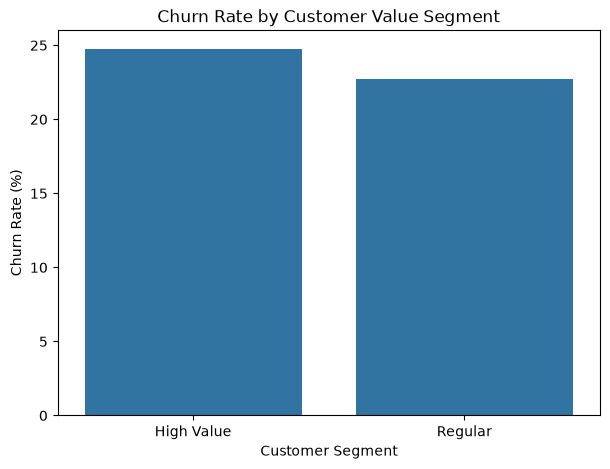

In [107]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=cltv_churn,
    x='customer_segment',
    y='churn_rate'
)

plt.title('Churn Rate by Customer Value Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Churn Rate (%)')

plt.show()

In [108]:
cancellation_plan = (
    df[df['churn_flag'] == 1]
    .groupby(['plan_type', 'cancellation_reason'])
    .size()
    .reset_index(name='customers')
)

cancellation_plan

,plan_type,cancellation_reason,customers
0,Basic,Competitor,177
1,Basic,Moved,193
2,Basic,Price,219
3,Basic,Service,187
4,Premium,Competitor,218
5,Premium,Moved,207
6,Premium,Price,208
7,Premium,Service,200
8,Standard,Competitor,190
9,Standard,Moved,208


In [109]:
cancellation_plan['reason_share_pct'] = (
    cancellation_plan['customers']
    / cancellation_plan.groupby('plan_type')['customers'].transform('sum')
    * 100
).round(2)

cancellation_plan

,plan_type,cancellation_reason,customers,reason_share_pct
0,Basic,Competitor,177,22.81
1,Basic,Moved,193,24.87
2,Basic,Price,219,28.22
3,Basic,Service,187,24.10
4,Premium,Competitor,218,26.17
5,Premium,Moved,207,24.85
6,Premium,Price,208,24.97
7,Premium,Service,200,24.01
8,Standard,Competitor,190,24.90
9,Standard,Moved,208,27.26


## Insight

Cancellation drivers vary across plans: **Price** is the leading reason among Basic customers (28.22%), **Moved** is the leading reason among Standard customers (27.26%), and **Competitor** is the largest reason among Premium customers (26.17%).

**Business implication:** Retention strategies should be tailored by plan rather than applying a single approach across all customers.


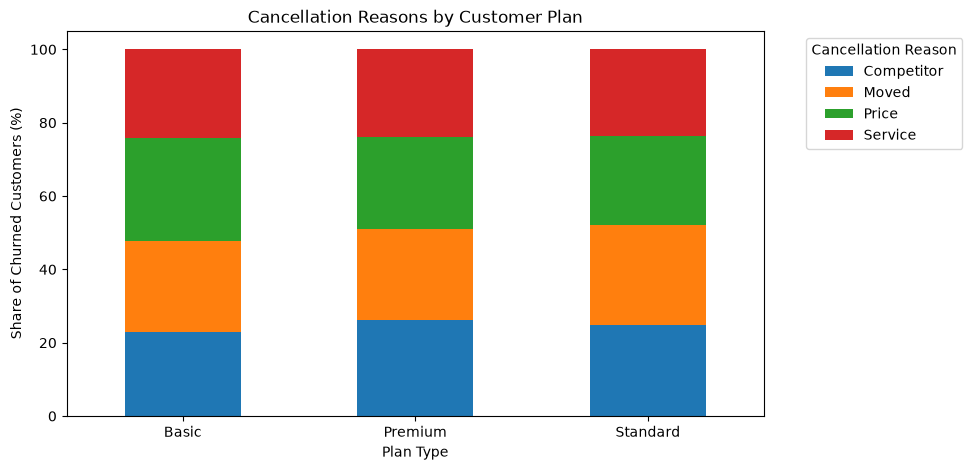

In [110]:
cancellation_pivot = cancellation_plan.pivot(
    index='plan_type',
    columns='cancellation_reason',
    values='reason_share_pct'
)

cancellation_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 5)
)

plt.title('Cancellation Reasons by Customer Plan')
plt.xlabel('Plan Type')
plt.ylabel('Share of Churned Customers (%)')
plt.legend(title='Cancellation Reason', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)

plt.show()

# Key Business Insights

### 1. Churn is a significant retention challenge
The overall customer churn rate is **23.72%**, meaning nearly one in four customers has churned.

### 2. Premium customers represent the largest financial exposure
Premium customers account for **55.43% of the monthly revenue associated with churned customers**, making this the most financially important segment for retention.

### 3. Premium–Quarterly is the highest-risk plan combination
The **Premium–Quarterly** segment has the highest churn rate at **26.12%** among the nine plan–contract combinations.

### 4. High-value customers require greater retention focus
High-value customers have a **24.76% churn rate** and represent **77.03% of total CLTV**, making them the highest-priority segment from a customer-value perspective.

### 5. Churn drivers differ by plan
- **Basic:** Price (28.22%)
- **Standard:** Moved (27.26%)
- **Premium:** Competitor (26.17%)

### 6. CSAT alone does not strongly differentiate churn
Churn rates across CSAT scores range from **22.33% to 23.86%**, suggesting that CSAT alone is not sufficient to explain churn in this dataset.

# Business Recommendations

### 1. Prioritize Premium retention
Focus retention resources on Premium customers because they represent the largest share of monthly revenue exposure from churned customers. Use personalized outreach, loyalty benefits, and stronger value/competitive positioning.

### 2. Investigate Premium–Quarterly churn
The Premium–Quarterly segment has the highest churn rate (**26.12%**). Investigate pricing/value perception, contract flexibility, competitor offers, and customer experience before designing targeted interventions.

### 3. Tailor retention by plan
- **Basic:** Test price/value-oriented retention offers.
- **Standard:** Develop continuity and win-back strategies for customers citing relocation.
- **Premium:** Strengthen competitive differentiation and overall value proposition.

### 4. Protect high-value customers
High-value customers represent **77.03% of total CLTV**. Prioritize proactive retention for this segment because improvements in retention can protect a disproportionate share of customer lifetime value.